In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [2]:
# ==========================================
# 2. Load Dataset
# ==========================================
df = pd.read_csv("survey_lung_cancer.csv")
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (309, 16)
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                  

In [3]:
# ==========================================
# 3. Preprocessing
# ==========================================
# Drop duplicates
df.drop_duplicates(inplace=True)

# Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Separate features & target
X = df.drop("LUNG_CANCER", axis=1)   # adjust if target column name is different
y = df["LUNG_CANCER"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# ==========================================
# 4. Handle Class Imbalance with SMOTE
# ==========================================
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

print("Before SMOTE:", np.bincount(y))
print("After SMOTE:", np.bincount(y_resampled))

Before SMOTE: [ 38 238]
After SMOTE: [238 238]


In [5]:
# ==========================================
# 5. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)


In [6]:
# ==========================================
# 6. Define Base Models
# ==========================================
base_learners = [
    ('cat', CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0, random_seed=42)),
    ('xgb', XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.1, subsample=1.0, colsample_bytree=0.7, eval_metric="logloss", random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42))
]

In [7]:
# ==========================================
# 7. Stacking Ensemble
# ==========================================
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Train
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('cat',
                                <catboost.core.CatBoostClassifier object at 0x000001D5411A4E50>),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.7, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_w...
                                              multi_strategy=None,
                                              n_estimators=500, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgbm',
                                LGBMClassifier(learning_rate=0.05,
                                               n_estimators=500,
                                               random_state=42)),
                               ('ada',
                                AdaBoostClassifier(learning_rate=0.5,
                                                   n_estimators=300,
                                                   random_state=42)),
                               ('rf',
                                RandomForestClassifier(max_depth=8,
                                                       n_estimators=500,
                                                       random_state=42))],
                   final_estimator=LogisticRegression(), n_jobs=-1)


 Stacked Model Results
Accuracy: 0.96875
ROC AUC: 0.9917534722222222

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        48
           1       0.98      0.96      0.97        48

    accuracy                           0.97        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.97      0.97      0.97        96



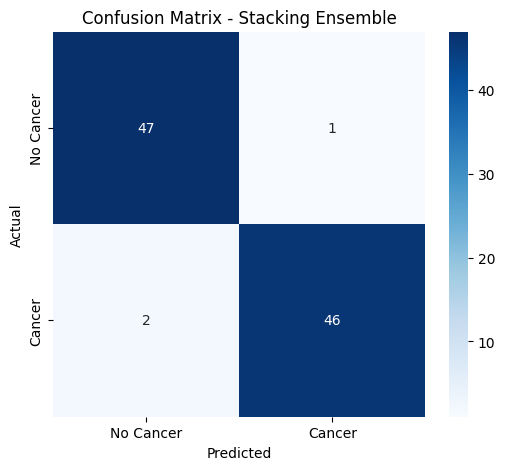

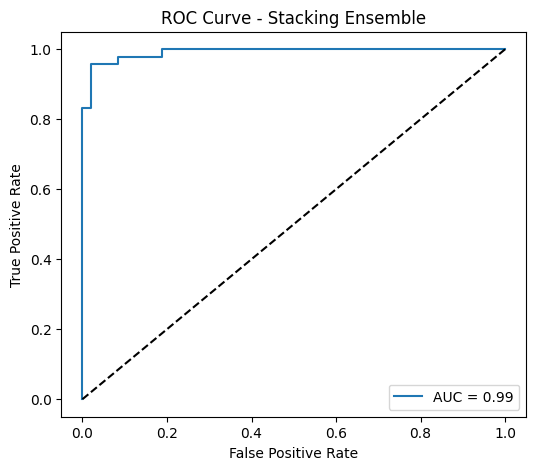

In [8]:
# ==========================================
# 8. Evaluation
# ==========================================
y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n Stacked Model Results")
print("Accuracy:", acc)
print("ROC AUC:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Cancer","Cancer"], yticklabels=["No Cancer","Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")
plt.legend()
plt.show()

In [9]:
# ==========================================
# 9. Cross-validation
# ==========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(stack_model, X_resampled, y_resampled, cv=cv, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



Cross-validation scores: [0.96875    0.96842105 0.92631579 0.95789474 0.94736842]
Mean CV Accuracy: 0.95375


In [10]:
# ==========================================
# 10. Save Model
# ==========================================
joblib.dump(stack_model, "lung_cancer_stacking_model.pkl")
print("Model saved as lung_cancer_stacking_model.pkl")

Model saved as lung_cancer_stacking_model.pkl


In [12]:
from sklearn.model_selection import train_test_split

# Original dataset
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Save test data for later use
test_data = pd.concat([X_test, y_test], axis=1)
test_data.to_csv("E:/SAI\Akhil_/VTPML03/CODE/test_data.csv", index=False)
print(" Test data saved as data/test_data.csv")

 Test data saved as data/test_data.csv
